# Verify `_add.pkl` cache labels against `metrics_out/`

Loads a relabeled cache (`dataset_cache_<brain>_mcl<N>_add.pkl`), rebuilds the
per-neuron split / merge / omit statistics **from the baked-in canonical labels
alone** (no segmentation read), and compares them to the canonical
`metrics_out/<brain>/<seg_id>/results.csv`.

## Should these match exactly?

**Close — and the residual gaps are explainable, not bugs.** The cache stores
fragments that were filtered at `min_cable_length` (100 µm), while the canonical
pipeline scores against the *unfiltered* skeletons. With the canonical merge
definition now fully reproduced — node-count rule **plus the geometric fragment
walk** (`MergeCountMetric`), baked into the cache as `gt_merge_labels` — the
expected behavior is:

- **% Omit Edges** — cache-only runs slightly **higher** (filtered-out short
  fragments leave GT stretches unlabeled → counted as omit). Upper bound on the
  true miss rate.
- **# Splits / % Split Edges** — cache-only runs slightly **lower / comparable**
  (fewer fragments → fewer distinct segments touching a neuron).
- **% Merged Edges** — should now track canonical **closely**, including the
  merge-heavy neurons (e.g. N013, N018) that the node-count rule alone missed,
  because the geometric walk recovers grazing fusions.
- **Edge Accuracy** — tracks canonical within the omit + residual-merge gaps.

The point of this notebook is to confirm the numbers are *consistent in shape*
(same neurons, same ranking, gaps in the expected direction and magnitude) — not
byte-equal. Kernel: **panda**.

> Requires an `_add.pkl` built with the geometric walk (current `relabel_cache.py`).
> Rerun `scripts/relabel_cache.py --brain <id>` if the merge labels look empty.

## 0. Setup

In [1]:
import os, sys, glob, pickle
from collections import defaultdict

import numpy as np
import pandas as pd

REPO = "/allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent"
sys.path.insert(0, os.path.join(REPO, "agentic-neuron-proofreader/src"))

from agentic_neuron_proofreader.data_modules import canonical_labeling as cl
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# Brain to verify. 789202 is the one with a results.csv in metrics_out/ here.
BRAIN_ID = "789202"
MINLEN = 100

CACHE_DIR = os.path.join(REPO, "exa-spim-agent/cache")
METRICS_DIR = os.path.join(REPO, "exa-spim-agent/metrics_out")
ADD_PATH = os.path.join(CACHE_DIR, f"dataset_cache_{BRAIN_ID}_mcl{MINLEN}_add.pkl")
print("add cache:", ADD_PATH, "\nexists:", os.path.exists(ADD_PATH))

add cache: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/cache/dataset_cache_789202_mcl100_add.pkl 
exists: True


## 1. Load the `_add.pkl` cache and confirm the labels are present

A relabeled cache carries `gt_node_canonical_label` and `gt_edge_error` (also
restored onto `gt_graph` as `node_label` / `edge_error`). If these are missing,
the cache was not relabeled — run `scripts/relabel_cache.py` first.

In [2]:
ds = BrainDataset.load_from_cache(ADD_PATH)
gt = ds.gt_graph

assert getattr(gt, "node_label", None) is not None, \
    "node_label missing — this cache was not relabeled (run relabel_cache.py)."
assert getattr(gt, "edge_error", None) is not None, \
    "edge_error missing — this cache was not relabeled."

node_label = np.asarray(gt.node_label)
edge_error = np.asarray(gt.edge_error)
n_labeled = int((node_label != cl.UNLABELED).sum())

print(gt.summary(prefix="GroundTruth"))
print(f"\nnode_label: shape={node_label.shape}, labeled={n_labeled:,} "
      f"({100*n_labeled/node_label.size:.1f}%)")
print(f"edge_error: shape={edge_error.shape}, classes="
      + ", ".join(f"{cl.EDGE_ERROR_NAMES[c]}={int((edge_error==c).sum())}"
                  for c in cl.EDGE_ERROR_NAMES))
print("segmentation_path:", ds.segmentation_path)

GroundTruth Graph
# Connected Components: 12
# Nodes: 1,409,057
# Edges: 1,409,045
Memory Consumption: 43.81 GBs

node_label: shape=(1409057,), labeled=1,369,807 (97.2%)
edge_error: shape=(1409045,), classes=correct=1109034, split=6805, omit=44690, merged=248516
segmentation_path: gs://allen-nd-goog/from_google/789202/whole_brain/raw.unet_r3_ckpt_425250_seedfix_overlapfix_rempm/


## 2. Whole-brain summary from the labels (no segmentation read)

`canonical_labeling.summarize` reproduces the same totals `relabel_cache.py`
printed — a quick self-consistency check that the stored arrays load cleanly.

In [3]:
# Merge labels stored in the cache = union of node-count rule + geometric walk
# (reproduces canonical labels_with_merge). Fall back to node-count-only if the
# cache predates the geometric walk.
merge_label_set = set(int(x) for x in (getattr(gt, "merge_labels", None)
                                       if getattr(gt, "merge_labels", None) is not None else []))
if not merge_label_set:
    merge_label_set = cl.merge_labels(gt, node_label)
    print("note: no stored geometric merge labels; using node-count rule only "
          "(rerun relabel_cache.py to bake the geometric walk in)")
print(f"merge labels: {len(merge_label_set)}")

summary = cl.summarize(gt, node_label, edge_error, merge_label_set=merge_label_set)
for k, v in summary.items():
    print(f"  {k:<18}: {v:.3f}" if isinstance(v, float) else f"  {k:<18}: {v}")

merge labels: 64
  num_edges         : 1409045
  pct_split_edges   : 0.483
  pct_omit_edges    : 3.172
  pct_merged_edges  : 17.655
  pct_merged_edges_per_edge_view: 17.637
  pct_correct_edges : 78.708
  total_splits      : 9433
  total_merges      : 10
  num_neurons       : 12


## 3. Per-neuron statistics from the cache labels

Build one row per GT neuron, mirroring the columns in `results.csv`. Both
endpoints of a GT edge live on the same neuron, so we label each edge by the GT
neuron of one endpoint and tally its class from `edge_error`.

- **# Splits** = (distinct predicted segments touching the neuron) − 1
- **% Split / Omit Edges** = class fraction of that neuron's GT edges
- **% Merged Edges** = canonical node-based formula `Σ (nodes_of_merge_label − 1)`
  over the union merge-label set (node-count rule + geometric walk), ÷ neuron edges
- **Edge Accuracy** = % correct edges
- **SWC Run Length** = cable length (µm), from the graph geometry

In [4]:
edges = list(gt.edges)

# neuron -> {class: edge count}, and neuron -> set of predicted segments on it
neuron_class = defaultdict(lambda: defaultdict(int))
neuron_segs = defaultdict(set)

for k, (i, j) in enumerate(edges):
    neuron = gt.node_segment_id(i)            # GT neuron name (both ends agree)
    neuron_class[neuron][int(edge_error[k])] += 1

for n in gt.nodes:
    lab = int(node_label[n])
    if lab != cl.UNLABELED:
        neuron_segs[gt.node_segment_id(n)].add(lab)

# --- Merged edges, the CANONICAL way -----------------------------------------
# Canonical % Merged Edges is NOT a graph-edge fraction: it is
#   sum over merge-labels on the neuron of (nodes_of_that_label_on_neuron - 1),
# divided by the neuron's edge count, over labels_with_merge -- the UNION of the
# node-count rule and the geometric fragment walk (merge_label_set from above).
seg_neuron_counts = cl.segment_neuron_node_counts(gt, node_label)
neuron_merged_edges = defaultdict(int)
for lab in merge_label_set:
    for neuron, c in seg_neuron_counts.get(lab, {}).items():
        neuron_merged_edges[neuron] += max(c - 1, 0)

# Cable length (µm) per neuron via connected components.
import networkx as nx
neuron_cable = {}
for comp in nx.connected_components(gt):
    root = next(iter(comp))
    neuron_cable[gt.node_segment_id(root)] = gt.cable_length(root=root)

rows = []
for neuron, classes in neuron_class.items():
    tot = sum(classes.values())
    n_split = classes.get(cl.EDGE_SPLIT, 0)
    n_omit = classes.get(cl.EDGE_OMIT, 0)
    n_correct = classes.get(cl.EDGE_CORRECT, 0)
    rows.append({
        "neuron": neuron,
        "SWC Run Length": neuron_cable.get(neuron, np.nan),
        "# Splits": max(len(neuron_segs[neuron]) - 1, 0),
        "% Split Edges": 100.0 * n_split / tot if tot else 0.0,
        "% Omit Edges": 100.0 * n_omit / tot if tot else 0.0,
        # canonical node-based formula over the union merge-label set
        "% Merged Edges": 100.0 * neuron_merged_edges[neuron] / tot if tot else 0.0,
        "Edge Accuracy": 100.0 * n_correct / tot if tot else 0.0,
    })

cache_df = pd.DataFrame(rows).set_index("neuron").sort_index()
print(f"{len(cache_df)} neurons")
cache_df

12 neurons


,SWC Run Length,# Splits,% Split Edges,% Omit Edges,% Merged Edges,Edge Accuracy
neuron,,,,,,
N005-789202-SP,430924.171005,1014,0.544159,4.786019,8.592369,86.092185
N006-789202-JG,695490.157652,1124,0.459978,1.640609,14.305500,83.606862
N007-789202-PP,261862.901699,557,0.491150,6.105164,2.175963,91.236847
N010-789202-JT,287269.918266,1230,1.449215,6.437858,4.107967,88.038404
N011-789202-IG,238901.271361,646,0.603065,4.642748,1.800700,92.958584
N013-789202-KS,634269.158024,736,0.395874,2.087274,40.468808,57.086397
N016-789202-HP,658480.057562,595,0.326896,0.847250,16.301118,82.534642
N018-789202-JM,813114.529474,536,0.273390,0.358608,43.064525,56.334018
N020-789202-PP,216578.968353,332,0.559290,1.190284,8.154522,90.099489


## 4. Load canonical `results.csv` and align on neuron name

In [5]:
hits = glob.glob(os.path.join(METRICS_DIR, BRAIN_ID, "*", "results.csv"))
assert hits, f"no results.csv under {METRICS_DIR}/{BRAIN_ID}"
canon_df = pd.read_csv(sorted(hits)[0], index_col=0).sort_index()
print("canonical:", sorted(hits)[0])
print(f"{len(canon_df)} neurons")

common = sorted(set(cache_df.index) & set(canon_df.index))
only_cache = sorted(set(cache_df.index) - set(canon_df.index))
only_canon = sorted(set(canon_df.index) - set(cache_df.index))
print(f"\ncommon neurons: {len(common)}")
if only_cache:
    print(f"only in cache : {only_cache}")
if only_canon:
    print(f"only in canon : {only_canon}")
canon_df

canonical: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/metrics_out/789202/raw.unet_r3_ckpt_425250_seedfix_overlapfix_rempm/results.csv
12 neurons

common neurons: 12


,SWC Run Length,# Splits,# Merges,% Split Edges,% Omit Edges,% Merged Edges,ERL,Normalized ERL,Edge Accuracy,Split Rate,Merge Rate
N005-789202-SP,6.600023e+05,1061.0,9,0.421502,3.948402,8.648018,2916.69,0.0044,86.98,594.87,70128.98
N006-789202-JG,1.093291e+06,1200.0,11,0.285244,1.155553,14.679720,5038.70,0.0046,83.88,897.95,97958.09
N007-789202-PP,4.018429e+05,582.0,5,0.370824,5.354540,2.313584,2336.16,0.0058,91.96,650.92,75767.19
N010-789202-JT,4.555105e+05,1390.0,3,0.936992,5.037188,3.984077,1403.83,0.0031,90.04,308.13,142765.84
N011-789202-IG,3.589280e+05,675.0,1,0.481845,3.594476,1.795562,2027.03,0.0056,94.13,510.07,344296.97
N013-789202-KS,9.324719e+05,782.0,37,0.212215,1.837686,41.040640,3161.85,0.0034,56.91,1167.98,24685.33
N016-789202-HP,1.050328e+06,641.0,11,0.177426,0.620928,14.954279,6306.73,0.0060,84.25,1625.49,94722.03
N018-789202-JM,1.237078e+06,564.0,4,0.115830,0.244194,42.930046,4159.44,0.0034,56.71,2185.50,308156.08
N020-789202-PP,3.490545e+05,357.0,1,0.290955,0.817224,7.863124,9296.58,0.0266,91.03,966.91,345186.31
N021-789202-HP,6.863528e+05,616.0,7,0.231252,1.998720,3.209231,6072.15,0.0088,94.56,1089.36,95863.91


## 5. Side-by-side comparison

For each shared column we show cache vs canonical and their difference. Read the
signs against the expectations in the header:

- `% Omit Edges` — **cache ≥ canonical** (filtering inflates omits).
- `# Splits`, `% Split Edges`, `Edge Accuracy` — close, no systematic large bias.
- `% Merged Edges` — should now be **close** across all neurons (node-count rule
  + geometric walk). A residual on a few neurons is the small set of merge labels
  the canonical dedup/branch-snapping handles slightly differently.

In [6]:
compare_cols = ["# Splits", "% Split Edges", "% Omit Edges",
                "% Merged Edges", "Edge Accuracy"]

cmp = pd.DataFrame(index=common)
for col in compare_cols:
    cmp[(col, "cache")] = cache_df.loc[common, col]
    cmp[(col, "canon")] = canon_df.loc[common, col]
    cmp[(col, "diff")] = cache_df.loc[common, col] - canon_df.loc[common, col]
cmp.columns = pd.MultiIndex.from_tuples(cmp.columns)

with pd.option_context("display.float_format", lambda v: f"{v:.2f}"):
    display(cmp)

print("\nMean difference (cache - canon) across neurons:")
for col in compare_cols:
    d = cmp[(col, "diff")]
    print(f"  {col:<16}: mean={d.mean():+.2f}  median={d.median():+.2f}  "
          f"|max|={d.abs().max():.2f}")

# Splits                 % Split Edges            % Omit Edges  \
                  cache   canon    diff         cache canon diff        cache   
N005-789202-SP     1014 1061.00  -47.00          0.54  0.42 0.12         4.79   
N006-789202-JG     1124 1200.00  -76.00          0.46  0.29 0.17         1.64   
N007-789202-PP      557  582.00  -25.00          0.49  0.37 0.12         6.11   
N010-789202-JT     1230 1390.00 -160.00          1.45  0.94 0.51         6.44   
N011-789202-IG      646  675.00  -29.00          0.60  0.48 0.12         4.64   
N013-789202-KS      736  782.00  -46.00          0.40  0.21 0.18         2.09   
N016-789202-HP      595  641.00  -46.00          0.33  0.18 0.15         0.85   
N018-789202-JM      536  564.00  -28.00          0.27  0.12 0.16         0.36   
N020-789202-PP      332  357.00  -25.00          0.56  0.29 0.27         1.19   
N021-789202-HP      583  616.00  -33.00          0.38  0.23 0.14         2.36   
N022-789202-JG     1301 1387.00  -86.00          0.57  0.39 0.18         4.36   
N023-789202-SP      779  794.00  -15.00          0.45  0.42 0.04        12.68   

                          % Merged Edges             Edge Accuracy              
               canon diff          cache canon  diff         cache canon  diff  
N005-789202-SP  3.95 0.84           8.59  8.65 -0.06         86.09 86.98 -0.89  
N006-789202-JG  1.16 0.49          14.31 14.68 -0.37         83.61 83.88 -0.27  
N007-789202-PP  5.35 0.75           2.18  2.31 -0.14         91.24 91.96 -0.72  
N010-789202-JT  5.04 1.40           4.11  3.98  0.12         88.04 90.04 -2.00  
N011-789202-IG  3.59 1.05           1.80  1.80  0.01         92.96 94.13 -1.17  
N013-789202-KS  1.84 0.25          40.47 41.04 -0.57         57.09 56.91  0.18  
N016-789202-HP  0.62 0.23          16.30 14.95  1.35         82.53 84.25 -1.72  
N018-789202-JM  0.24 0.11          43.06 42.93  0.13         56.33 56.71 -0.38  
N020-789202-PP  0.82 0.37           8.15  7.86  0.29         90.10 91.03 -0.93  
N021-789202-HP  2.00 0.36           3.15  3.21 -0.06         94.12 94.56 -0.44  
N022-789202-JG  3.81 0.56          13.10 13.83 -0.72         81.98 81.98 -0.00  
N023-789202-SP 11.75 0.93           3.76  3.95 -0.18         83.10 83.89 -0.79


Mean difference (cache - canon) across neurons:
  # Splits        : mean=-51.33  median=-39.50  |max|=160.00
  % Split Edges   : mean=+0.18  median=+0.15  |max|=0.51
  % Omit Edges    : mean=+0.61  median=+0.52  |max|=1.40
  % Merged Edges  : mean=-0.02  median=-0.06  |max|=1.35
  Edge Accuracy   : mean=-0.76  median=-0.75  |max|=2.00


## 6. Consistency checks (shape, not equality)

We assert the relationships that *should* hold, and only warn (don't fail) on the
ones expected to diverge. A FAIL here points to a real labeling problem; a WARN
is the documented filtering/definition gap.

In [7]:
def report(name, ok, detail="", hard=True):
    tag = ("PASS" if ok else "FAIL") if hard else ("OK" if ok else "WARN")
    print(f"[{tag}] {name}" + (f"  ->  {detail}" if detail else ""))
    return ok

# Same neuron set (hard): the cache and canonical should trace the same neurons.
report("same GT neuron set", not only_cache and not only_canon,
       f"cache-only={only_cache}, canon-only={only_canon}")

# Omit should be inflated cache-side, not deflated (hard direction check).
omit_diff = cmp[("% Omit Edges", "diff")]
report("% Omit Edges: cache >= canonical (filtering inflates omits)",
       (omit_diff >= -0.5).all(),
       f"min diff={omit_diff.min():+.2f}, mean={omit_diff.mean():+.2f}")

# Split %, # Splits, Edge Accuracy should correlate strongly across neurons.
for col in ["Edge Accuracy", "% Split Edges", "# Splits"]:
    r = np.corrcoef(cache_df.loc[common, col], canon_df.loc[common, col])[0, 1]
    report(f"{col}: cache vs canonical correlated (r > 0.7)", r > 0.7,
           f"r={r:.3f}", hard=False)

# Merged edges now use the full canonical definition (node-count + geometric
# walk) -> expect strong correlation and a modest mean gap.
md = cmp[("% Merged Edges", "diff")]
r_merge = np.corrcoef(cache_df.loc[common, "% Merged Edges"],
                      canon_df.loc[common, "% Merged Edges"])[0, 1]
report("% Merged Edges: cache vs canonical correlated (r > 0.7)",
       r_merge > 0.7, f"r={r_merge:.3f}", hard=False)
report("% Merged Edges: mean |diff| within 5 pts",
       md.abs().mean() < 5, f"mean |diff|={md.abs().mean():.2f}", hard=False)

print("\nFAIL = real problem to investigate; WARN = documented filtering/definition gap.")
print("(If % Merged Edges is still far off on N013/N018, the geometric walk was not")
print(" baked in -- rerun relabel_cache.py so gt_merge_labels is populated.)")

[PASS] same GT neuron set  ->  cache-only=[], canon-only=[]
[PASS] % Omit Edges: cache >= canonical (filtering inflates omits)  ->  min diff=+0.11, mean=+0.61
[OK] Edge Accuracy: cache vs canonical correlated (r > 0.7)  ->  r=0.999
[OK] % Split Edges: cache vs canonical correlated (r > 0.7)  ->  r=0.957
[OK] # Splits: cache vs canonical correlated (r > 0.7)  ->  r=0.997
[OK] % Merged Edges: cache vs canonical correlated (r > 0.7)  ->  r=0.999
[OK] % Merged Edges: mean |diff| within 5 pts  ->  mean |diff|=0.33

FAIL = real problem to investigate; WARN = documented filtering/definition gap.
(If % Merged Edges is still far off on N013/N018, the geometric walk was not
 baked in -- rerun relabel_cache.py so gt_merge_labels is populated.)


## 7. Scatter: cache vs canonical per neuron

Points on the diagonal = agreement. Systematic offset from the diagonal = the
expected filtering/definition gap (e.g. omit points sitting above the line).

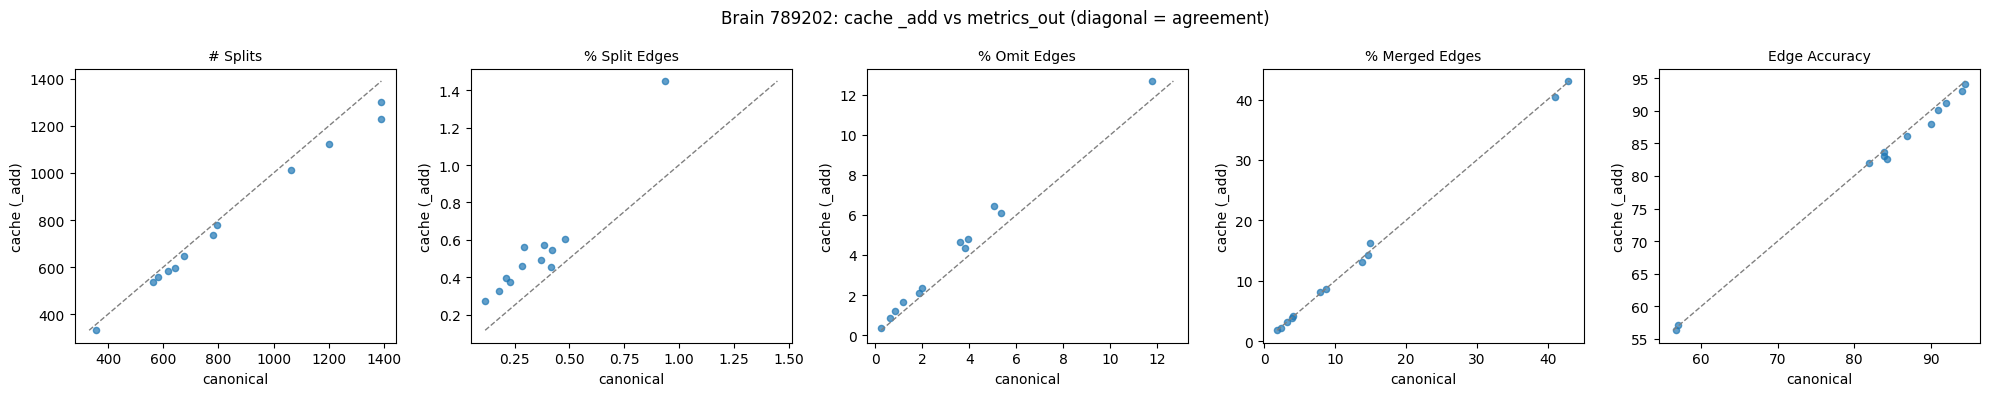

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(compare_cols), figsize=(4 * len(compare_cols), 4))
for ax, col in zip(axes, compare_cols):
    x = canon_df.loc[common, col].values
    y = cache_df.loc[common, col].values
    ax.scatter(x, y, s=20, alpha=0.7)
    lo = float(min(x.min(), y.min()))
    hi = float(max(x.max(), y.max()))
    ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
    ax.set_xlabel(f"canonical")
    ax.set_ylabel(f"cache (_add)")
    ax.set_title(col, fontsize=10)
fig.suptitle(f"Brain {BRAIN_ID}: cache _add vs metrics_out (diagonal = agreement)")
fig.tight_layout()
plt.show()